<a href="https://www.kaggle.com/code/joshuanguyenolson/nlp-with-disaster-tweets-kerasnlp-distilbert?scriptVersionId=325660307" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<a href="https://www.kaggle.com/code/joshuanguyenolson/nlp-getting-started" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# NLP with Disaster Tweets: KerasNLP DistilBERT
**Updated:** 2026-06-09  
**Goal:** Predict whether a tweet describes a real disaster  
**Metric:** F1 Score (binary)  
**Approach:** KerasNLP DistilBERT fine-tuning + keyword/location feature awareness

## 1. Setup & Imports

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import keras
import keras_nlp

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

2026-06-09 15:07:55.658221: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781017675.845600      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781017675.902830      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781017676.369062      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781017676.369117      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781017676.369122      23 computation_placer.cc:177] computation placer alr

/kaggle/input/models/keras/distil_bert/keras/distil_bert_base_en_uncased/3/config.json
/kaggle/input/models/keras/distil_bert/keras/distil_bert_base_en_uncased/3/tokenizer.json
/kaggle/input/models/keras/distil_bert/keras/distil_bert_base_en_uncased/3/metadata.json
/kaggle/input/models/keras/distil_bert/keras/distil_bert_base_en_uncased/3/model.weights.h5
/kaggle/input/models/keras/distil_bert/keras/distil_bert_base_en_uncased/3/assets/tokenizer/vocabulary.txt
/kaggle/input/competitions/nlp-getting-started/sample_submission.csv
/kaggle/input/competitions/nlp-getting-started/train.csv
/kaggle/input/competitions/nlp-getting-started/test.csv


## 2. Data Loading

In [2]:
train = pd.read_csv('/kaggle/input/competitions/nlp-getting-started/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/nlp-getting-started/test.csv')

print(f'Train: {train.shape} | Test: {test.shape}')
train.head()

Train: (7613, 5) | Test: (3263, 4)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


## 3. Exploratory Data Analysis

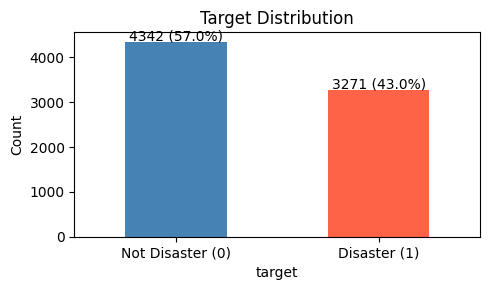

Class balance: 42.97% disaster tweets


In [3]:
# Target distribution
ax = train['target'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], figsize=(5, 3))
ax.set_xticklabels(['Not Disaster (0)', 'Disaster (1)'], rotation=0)
ax.set_title('Target Distribution')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{p.get_height()} ({p.get_height()/len(train)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2, p.get_height() + 30), ha='center')
plt.tight_layout()
plt.show()

print(f'Class balance: {train["target"].mean():.2%} disaster tweets')

In [4]:
# Missing values
missing = pd.DataFrame({
    'Train Missing': train.isnull().sum(),
    'Train %':       (train.isnull().sum() / len(train) * 100).round(1),
    'Test Missing':  test.isnull().sum(),
    'Test %':        (test.isnull().sum() / len(test) * 100).round(1)
}).query('`Train Missing` > 0 or `Test Missing` > 0')
print(missing)

          Train Missing  Train %  Test Missing  Test %
keyword              61      0.8          26.0     0.8
location           2533     33.3        1105.0    33.9


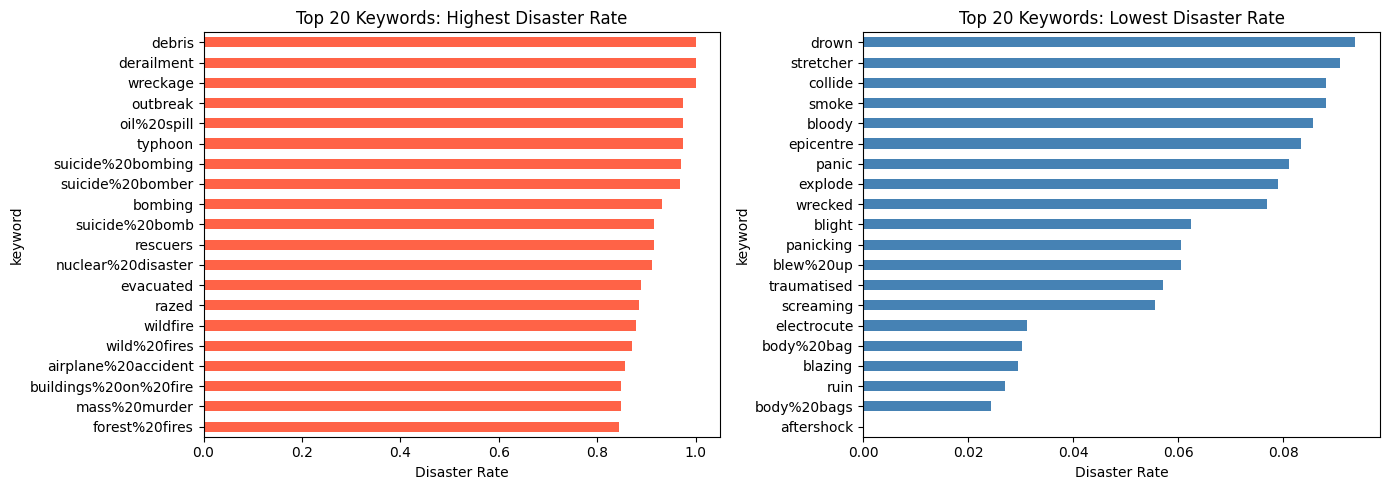

In [5]:
# Top keywords by disaster rate
kw_stats = (
    train.dropna(subset=['keyword'])
    .groupby('keyword')['target']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'disaster_rate', 'count': 'n'})
    .query('n >= 10')
    .sort_values('disaster_rate', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

kw_stats.head(20)['disaster_rate'].plot(kind='barh', ax=axes[0], color='tomato')
axes[0].set_title('Top 20 Keywords: Highest Disaster Rate')
axes[0].set_xlabel('Disaster Rate')
axes[0].invert_yaxis()

kw_stats.tail(20)['disaster_rate'].plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 20 Keywords: Lowest Disaster Rate')
axes[1].set_xlabel('Disaster Rate')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

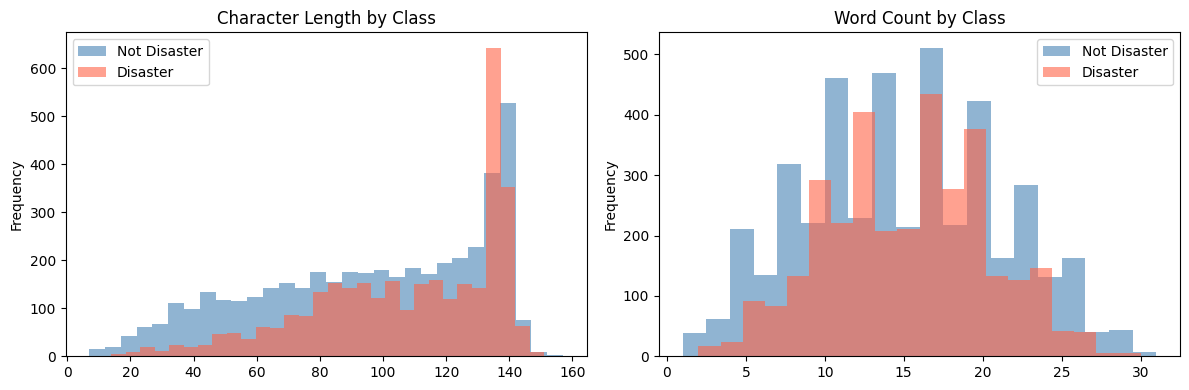

        char_len  word_len
target                    
0           95.7      14.7
1          108.1      15.2


In [6]:
# Tweet length distributions
train['char_len'] = train['text'].str.len()
train['word_len'] = train['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, color in [(0, 'steelblue'), (1, 'tomato')]:
    subset = train[train['target'] == label]
    subset['char_len'].plot(kind='hist', alpha=0.6, bins=30, ax=axes[0], color=color,
                            label=['Not Disaster', 'Disaster'][label])
    subset['word_len'].plot(kind='hist', alpha=0.6, bins=20, ax=axes[1], color=color,
                            label=['Not Disaster', 'Disaster'][label])

axes[0].set_title('Character Length by Class')
axes[0].legend()
axes[1].set_title('Word Count by Class')
axes[1].legend()
plt.tight_layout()
plt.show()

print(train.groupby('target')[['char_len', 'word_len']].mean().round(1))

In [7]:
# Sample tweets
print('=== Sample DISASTER tweets ===')
for t in train[train['target'] == 1]['text'].sample(5, random_state=SEED).values:
    print(f'  â€¢ {t}')

print('\n=== Sample NON-DISASTER tweets ===')
for t in train[train['target'] == 0]['text'].sample(5, random_state=SEED).values:
    print(f'  â€¢ {t}')

=== Sample DISASTER tweets ===
  â€¢ Nearly 50 thousand people affected by floods in #Paraguay ? http://t.co/aw23wXtyjB http://t.co/ABgct9VFUa
  â€¢ Vladimir Putin Issues Major Warning But Is It Too Late To Escape Armageddon?
http://t.co/gBxafy1m1C
  â€¢ @DoctorFluxx @StefanEJones @spinnellii @themermacorn  No burning buildings and rob during a riot. That's embarrassing &amp; ruining this nation.
  â€¢ Telnet attacked from 124.13.172.40 (STREAMYX-HOME-SOUTHERN MY)
  â€¢ LONDON IS DROWNING AND IIII LIVE BY THE RIVEEEEEER

=== Sample NON-DISASTER tweets ===
  â€¢ Everyday is a near death fatality for me on the road. Thank god is on my side.??
  â€¢ #Lifestyle Û÷It makes me sickÛª: Baby clothes deemed a Û÷hazardÛª http://t.co/0XrfVidxA2 http://t.co/oIHwgEZDCk
  â€¢ @Lenn_Len Probably. We are inundated with them most years!
  â€¢ A demoness with the voice of an angel. Like a siren's call beckoning me to the void. Don't ?? on thisÛ_ https://t.co/nPS3xpBKaQ
  â€¢ Next Man Up---AH SCREW 

**EDA Findings:**
- Dataset is ~57% non-disaster / 43% disaster. Mild imbalance; F1 is the right metric
- `keyword` ~0.8% missing, `location` ~33% missing. Location is too sparse to use reliably
- Keywords like `derailment`, `wreckage`, `debris` skew heavily toward real disasters
- Disaster tweets average slightly longer character length; subtle signal
- Tweet text is noisy (URLs, hashtags, @mentions). DistilBERT handles subword tokenization natively

## 4. Text Preprocessing

In [8]:
# Fill missing keyword; prepend keyword to tweet text for additional signal
for df in [train, test]:
    df['keyword'] = df['keyword'].fillna('').str.replace('%20', ' ')
    df['input_text'] = df.apply(
        lambda r: (r['keyword'] + ' ' + r['text']).strip() if r['keyword'] else r['text'],
        axis=1
    )

print('Sample input_text:')
train[['keyword', 'text', 'input_text']].head(3)

Sample input_text:


,keyword,text,input_text
0,,Our Deeds are the Reason of this #earthquake M...,Our Deeds are the Reason of this #earthquake M...
1,,Forest fire near La Ronge Sask. Canada,Forest fire near La Ronge Sask. Canada
2,,All residents asked to 'shelter in place' are ...,All residents asked to 'shelter in place' are ...


In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    train['input_text'].values,
    train['target'].values,
    test_size=0.2,
    stratify=train['target'].values,
    random_state=SEED
)

X_test = test['input_text'].values

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

Train: 6090 | Val: 1523 | Test: 3263


## 5. Model: KerasNLP DistilBERT Fine-Tuning

In [10]:
# Load pre-trained DistilBERT classifier from KerasNLP preset
classifier = keras_nlp.models.DistilBertClassifier.from_preset(
    'distil_bert_base_en_uncased',
    num_classes=2,
)

classifier.compile(
    optimizer=keras.optimizers.Adam(learning_rate=2e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

classifier.summary()

I0000 00:00:1781017696.107659      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Preprocessor: "distil_bert_text_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ distil_bert_tokenizer (DistilBertTokenizer)                   │                       Vocab size: 30,522 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "distil_bert_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ distil_bert_backbone          │ (None, None, 768)         │      66,362,880 │ padding_mask[0][0],        │
│ (DistilBertBackbone)          │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, 768)               │               0 │ distil_bert_backbone[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ get_item[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_dropout (Dropout)      │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 2)                 │           1,538 │ output_dropout[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 66,955,010 (255.41 MB)

 Trainable params: 66,955,010 (255.41 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
BATCH_SIZE = 32
EPOCHS     = 3

history = classifier.fit(
    x=X_train,
    y=y_train,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
)

Epoch 1/3


I0000 00:00:1781017720.611565      68 service.cc:152] XLA service 0x7fb878003e40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781017720.611604      68 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1781017723.554454      68 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1781017745.356386      68 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


191/191 ━━━━━━━━━━━━━━━━━━━━ 217s 921ms/step - accuracy: 0.8053 - loss: 0.4533 - val_accuracy: 0.8313 - val_loss: 0.3932
Epoch 2/3
191/191 ━━━━━━━━━━━━━━━━━━━━ 148s 775ms/step - accuracy: 0.8616 - loss: 0.3478 - val_accuracy: 0.8418 - val_loss: 0.3900
Epoch 3/3
191/191 ━━━━━━━━━━━━━━━━━━━━ 148s 775ms/step - accuracy: 0.8911 - loss: 0.2882 - val_accuracy: 0.8372 - val_loss: 0.4114


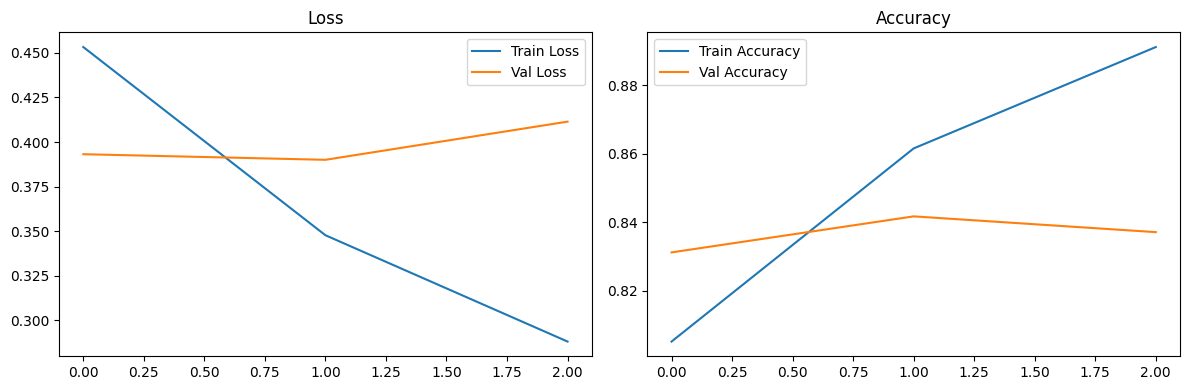

In [12]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Evaluation

In [13]:
# Predict on validation set
val_logits = classifier.predict(X_val, batch_size=BATCH_SIZE)
val_preds  = np.argmax(val_logits, axis=1)

val_f1 = f1_score(y_val, val_preds)
print(f'Validation F1 Score: {val_f1:.4f}')
print()
print(classification_report(y_val, val_preds, target_names=['Not Disaster', 'Disaster']))

48/48 ━━━━━━━━━━━━━━━━━━━━ 17s 287ms/step
Validation F1 Score: 0.8032

              precision    recall  f1-score   support

Not Disaster       0.84      0.88      0.86       869
    Disaster       0.83      0.77      0.80       654

    accuracy                           0.84      1523
   macro avg       0.84      0.83      0.83      1523
weighted avg       0.84      0.84      0.84      1523



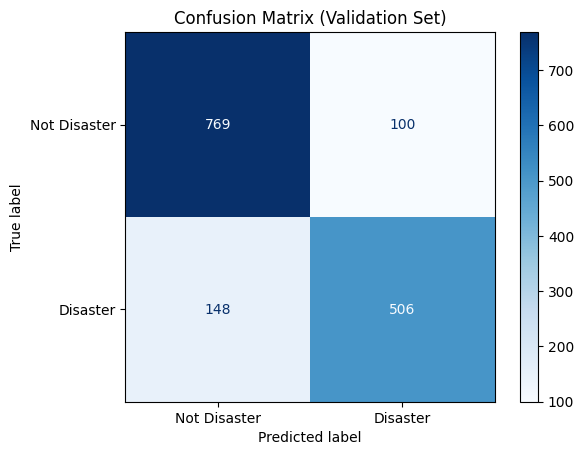

In [14]:
ConfusionMatrixDisplay.from_predictions(
    y_val, val_preds,
    display_labels=['Not Disaster', 'Disaster'],
    cmap='Blues'
)
plt.title('Confusion Matrix (Validation Set)')
plt.show()

## 7. Keyword Analysis

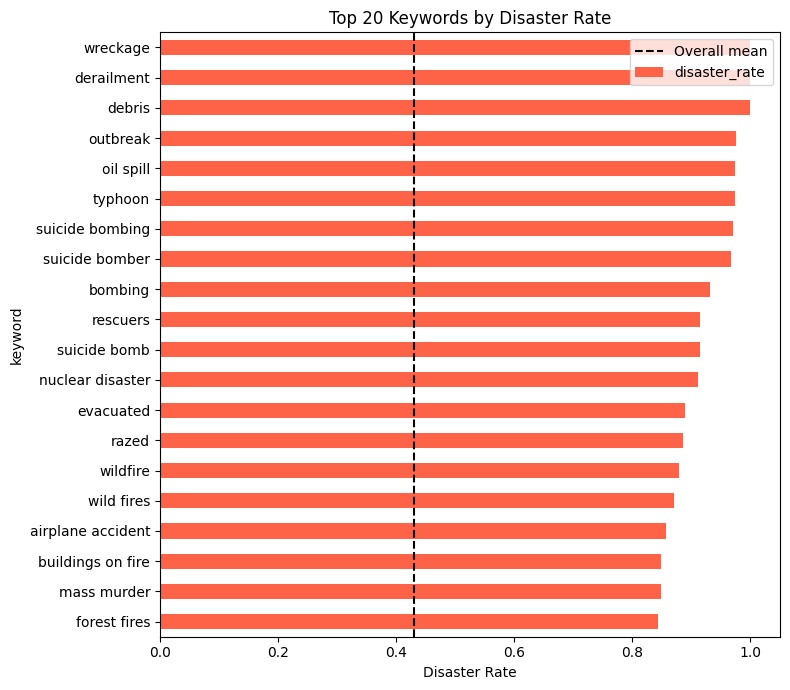

In [15]:
# Top 20 keywords with highest disaster rate (min 5 appearances)
top_kw = (
    train.dropna(subset=['keyword'])
    .groupby('keyword')['target']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'disaster_rate', 'count': 'n'})
    .query('n >= 5')
    .sort_values('disaster_rate', ascending=False)
    .head(20)
)

top_kw['disaster_rate'].sort_values().plot(
    kind='barh', figsize=(8, 7), color='tomato'
)
plt.title('Top 20 Keywords by Disaster Rate')
plt.xlabel('Disaster Rate')
plt.axvline(x=train['target'].mean(), color='black', linestyle='--', label='Overall mean')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Generate Submission

In [16]:
test_logits = classifier.predict(X_test, batch_size=BATCH_SIZE)
test_preds  = np.argmax(test_logits, axis=1)

submission = pd.DataFrame({
    'id':     test['id'],
    'target': test_preds
})

submission.to_csv('submission.csv', index=False)
print(f'Submission saved: {submission.shape[0]} rows')
print(f'Predicted disaster rate: {test_preds.mean():.2%}')
submission.head()

102/102 ━━━━━━━━━━━━━━━━━━━━ 27s 258ms/step
Submission saved: 3263 rows
Predicted disaster rate: 38.09%


,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1


## Summary
- **Model:** KerasNLP DistilBERT (`distil_bert_base_en_uncased`), 3 epochs, lr=2e-5, batch=32
- **Input:** keyword (URL-decoded) prepended to tweet text
- **Val F1:** see cell output above
- **Limitations:** No hyperparameter search; location column dropped (33% missing); 3 epochs may underfit
- **Next steps:** Try BERT-base or RoBERTa; add learning-rate warmup; experiment with longer max_sequence_length